 **Tarea: Mejorar la imagen**





size =  (463, 509)


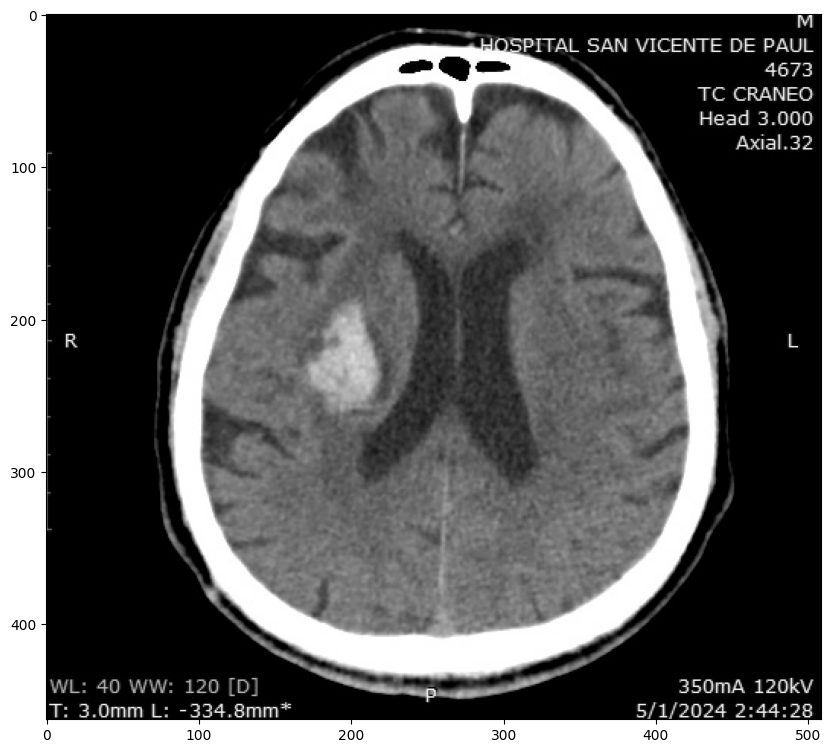

In [ ]:
#Carga de la imagen
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('ima2.jpeg',0)
print('size = ',img.shape)
plt.figure(figsize=(10,10))
plt.imshow(img,cmap='gray')
plt.show()

Muestreo

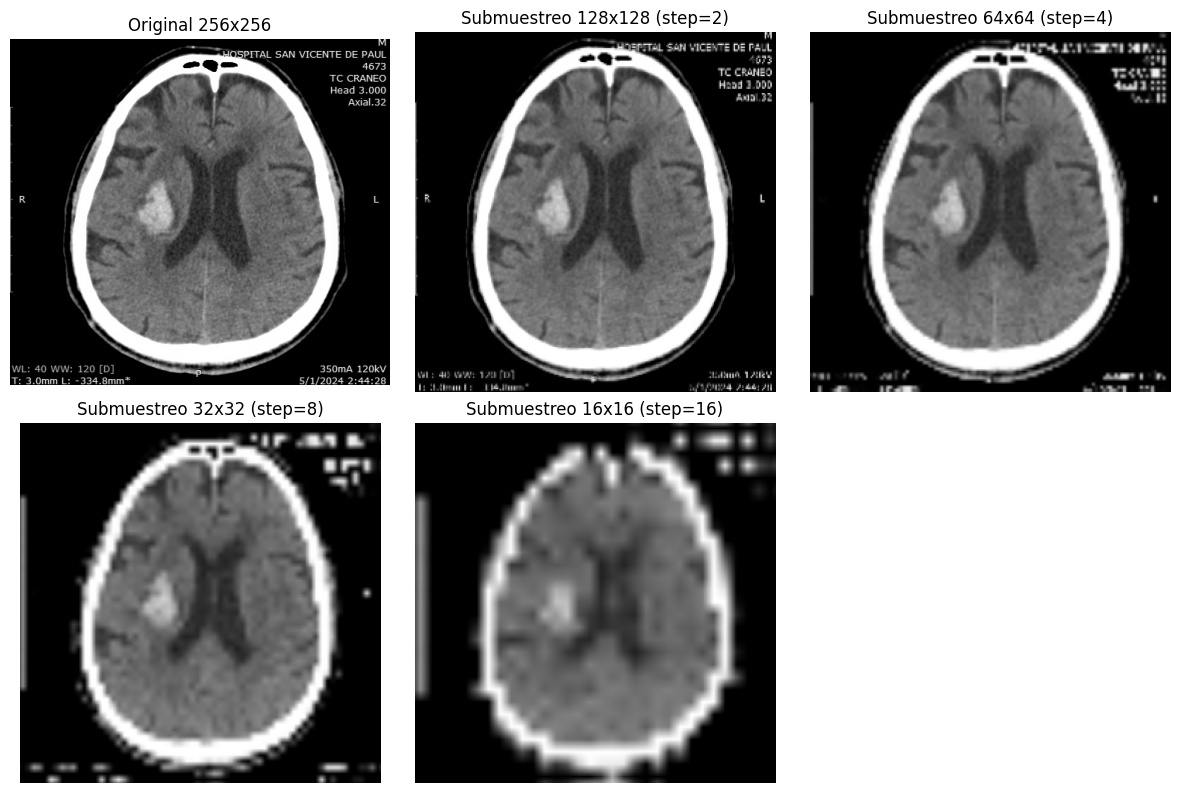

128 (232, 255)
64 (116, 128)
32 (58, 64)
16 (29, 32)


In [ ]:
#Submuestreo
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

#Imagen base (gris, 256x256)
#img = resize(img, (4, 256), anti_aliasing=True).astype(np.float32)

def subsample_every_k(img, k):
    """
    Submuestreo por 'tomar un píxel sí y (k-1) no' en filas y columnas.
    k=2 -> 128x128 (1 sí, 1 no)
    k=4 -> 64x64
    k=8 -> 32x32
    k=16 -> 16x16
    """
    return img[::k, ::k]

# Submuestreos solicitados (desde 256x256)
factors = {128: 2, 64: 4, 32: 8, 16: 16}
samples = {}
ups = {}

for size, k in factors.items():
    low = subsample_every_k(img, k)  # toma un píxel sí y k-1 no
    samples[size] = low
    # Volver a 256x256 solo para visualizar el efecto "pixelado"
    ups[size] = resize(low, (256, 256), anti_aliasing=False)

# Mostrar resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 256x256")
plt.axis("off")

for i, size in enumerate([128, 64, 32, 16], start=2):
    plt.subplot(2, 3, i)
    plt.imshow(ups[size], cmap="gray")
    k = factors[size]
    plt.title(f"Submuestreo {size}x{size} (step={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()

# (Opcional) Ver tamaños reales submuestreados
for size in [128, 64, 32, 16]:
    print(size, samples[size].shape)

#Conclusiones: Con 128x128 se mantiene una buena calidad para el análisis

Cuantización

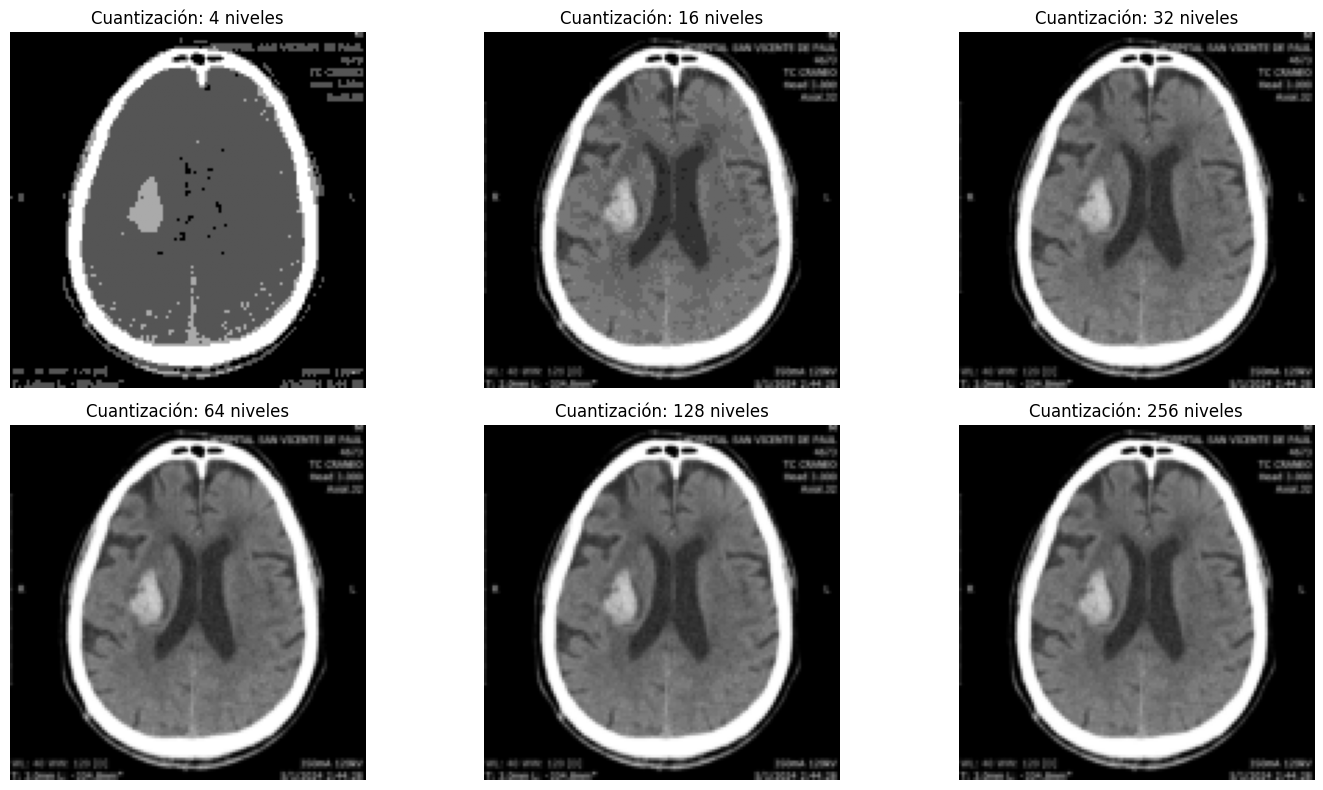

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# Imagen base (gris, 256x256)
img_128 = img[::1, ::1]


# -----------------------------
# 2) CUANTIZACIÓN DE INTENSIDAD (niveles de gris)
# -----------------------------
# Idea: mantener la misma resolución, pero reducir el número de niveles (bits).
def quantize_levels(x, levels):
    # x en [0,1]
    xq = np.round(x * (levels - 1)) / (levels - 1)
    return xq

# Niveles típicos: 2 (1 bit), 4 (2 bits), 16 (4 bits), 256 (8 bits)
levels_list = [4,16,32,64,128,256]
quantized = {L: quantize_levels(img_128, L) for L in levels_list}

plt.figure(figsize=(15, 8)) # Ajustado el figsize para 6 imágenes
for i, L in enumerate(levels_list, start=1):
    plt.subplot(2, 3, i) # Cambiado a 2 filas, 3 columnas
    plt.imshow(quantized[L], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Cuantización: {L} niveles")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Con 16 niveles sobre la imagen de 120 *128 se mantiene una buena imagen para segmentar mancha del centro del craneo

**Conectividad** (4 - 8)


Imagen astronauta binaria con umbral T = 0.6
Objetos (4-conectividad): 2
Objetos (8-conectividad): 2


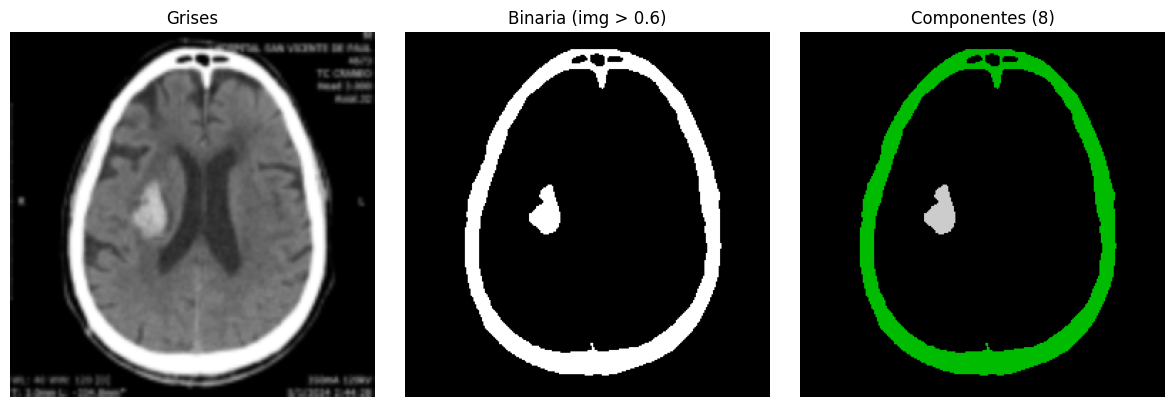

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label
from skimage import data, color
from skimage.transform import resize

# ----------------------------------------------------
# 1) Ejemplo con imagen real (cebra): binarizar y contar componentes
# ----------------------------------------------------

#En base al submuestreo, tomamos la imagen de 128 x 128
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

T = 0.60                       # umbral (ajústalo para ver diferentes resultados)
bw = (img > T).astype(np.uint8)

L4_img = label(bw, connectivity=1)
L8_img = label(bw, connectivity=2)

print("\nImagen astronauta binaria con umbral T =", T)
print("Objetos (4-conectividad):", int(L4_img.max()))
print("Objetos (8-conectividad):", int(L8_img.max()))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Grises"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(bw, cmap="gray"); plt.title(f"Binaria (img > {T})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(L8_img, cmap="nipy_spectral"); plt.title("Componentes (8)"); plt.axis("off")
plt.tight_layout()
plt.show()



Imagen astronauta binaria con umbral T = 0.6
Objetos (4-conectividad): 9
Objetos (8-conectividad): 8


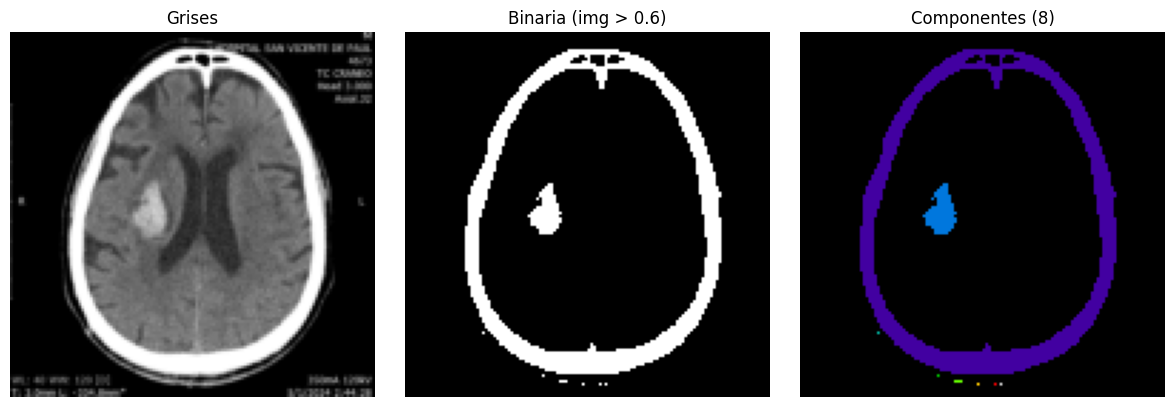

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label
from skimage import data, color
from skimage.transform import resize

# ----------------------------------------------------
# 1) Ejemplo con imagen real (cebra): binarizar y contar componentes
# ----------------------------------------------------

#En base al submuestreo, tomamos la imagen de 128 x 128
img_16 = quantized[64]

T = 0.60                       # umbral (ajústalo para ver diferentes resultados)
bw = (img_16 > T).astype(np.uint8)

L4_img = label(bw, connectivity=1)
L8_img = label(bw, connectivity=2)

print("\nImagen astronauta binaria con umbral T =", T)
print("Objetos (4-conectividad):", int(L4_img.max()))
print("Objetos (8-conectividad):", int(L8_img.max()))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_16, cmap="gray"); plt.title("Grises"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(bw, cmap="gray"); plt.title(f"Binaria (img > {T})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(L8_img, cmap="nipy_spectral"); plt.title("Componentes (8)"); plt.axis("off")
plt.tight_layout()
plt.show()

#Tenemos una buena definicion con un componentes de 8 sobre la imagen cuantizada de 64 niveles